# Rodando o Modelo

Aqui vou desenvolver a integracão com o modelo de deteccão de cancêr de mama.

Para isso vou usar o `huggingface_hub` para poder baixar o modelo. 
O `roboflow` para baixar e interagir com o dataset. 
Vou usar `logging` para garantir a compreensão do código ao longo da execucão.
E o `ultralytics` para obter o modelo original, já que o YOLO é o modelo base que foi treinado para a finalidade de deteccão de cancer de mama.
Adicionalmente incluí outros módulos para processamento da imagem `PIL`.


In [31]:
!pip install ultralytics huggingface roboflow huggingface_hub PIL

ERROR: Could not find a version that satisfies the requirement PIL (from versions: none)
ERROR: No matching distribution found for PIL


# Settando o ambiente

Deixando o ambiente funcional, aqui estão definidos os imports e as variáveis de ambiente.

In [ ]:
import roboflow
import os

from ultralytics import YOLO
from huggingface_hub import hf_hub_download
from PIL import Image

from random import choice
from logging import getLogger

from IPython.display import display as display_image

LOGGER = getLogger(__name__)
WORKSPACE = "med-2fnb4"
API_KEY = "BOTE A SUA API_KEY DO ROBOFLOW AQUI"

## Objeto do Modelo

Aqui é o objeto do modelo, definido para unificar a integracão do que deve ser o modelo de forma mais simplificada e estruturada.

In [47]:
class CancerDetector:

    def __init__(self, 
                 repo_id: str = "Jesteban247/yolo11-breast_cancer-onnx", 
                 filename: str = "best.onnx"):
        LOGGER.debug(f"Baixando {filename} de {repo_id}...")

        model_path = hf_hub_download(repo_id=repo_id, filename=filename)
        self.model = YOLO(model_path, task='detect')
        
        LOGGER.debug(f"Modelo carregado de {model_path}")

    def predict(self, 
                source, 
                save: bool = False, 
                conf: float = 0.25, 
                iou: float = 0.7, 
                device: str = 'cpu'):
        LOGGER.info(f"Executando previsão em {source} usando dispositivo: {device}...")
        
        results = self.model.predict(source=source, save=save, conf=conf, iou=iou, device=device)
        
        return results


### Obtencão do dataset

Para observar as capabilidades do modelo, foi obtido o dataset original e a partir dele serão feitas as observacões de que o modelo foi capaz de operar corretamente ou não.

In [48]:
def get_roboflow_dataset_version(project_name: str = "cancer-detection-dataset-vrorj", 
                                 api_key: str = None):
    
    rf = roboflow.Roboflow(api_key=api_key)
    
    project = rf.workspace(WORKSPACE).project(project_name)
    available_versions = project.versions()
    
    return [v.version for v in available_versions]

def get_roboflow_dataset(project_name: str = "cancer-detection-dataset-vrorj",
                         version: int = 2, dataset_format: str = "yolov8",
                         api_key: str = None):

    LOGGER.debug(f"Acessando o conjunto de dados Roboflow '{project_name}' versão {version}...")

    rf = roboflow.Roboflow(api_key=api_key)
    project = rf.workspace(WORKSPACE).project(project_name)
    dataset = project.version(version).download(model_format=dataset_format)

    LOGGER.debug(f"Conjunto de dados Roboflow '{project_name}' versão {version} baixado.")

    return dataset

#### Testes

Testando a integracão de todos os elementos

--- Executando Diagnóstico Final do Pipeline ---
loading Roboflow workspace...
loading Roboflow project...
Versões disponíveis do conjunto de dados Roboflow: ['2']
loading Roboflow workspace...
loading Roboflow project...
Loading /home/samuel/.cache/huggingface/hub/models--Jesteban247--yolo11-breast_cancer-onnx/snapshots/5b6786e19d36c721216682a1bcbbad6c898319f7/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.27.0 with CPUExecutionProvider

image 1/1 /home/samuel/dev/IA/final_val.jpg: 640x640 1 BC, 38.5ms
Speed: 0.9ms preprocess, 38.5ms inference, 14.3ms postprocess per image at shape (1, 3, 640, 640)


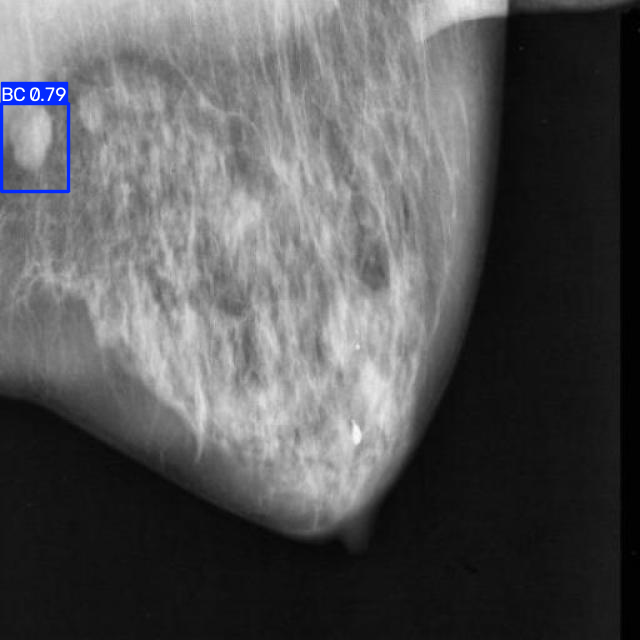

In [ ]:
cancer_detector = CancerDetector()

print("--- Executando Diagnóstico Final do Pipeline ---")

if API_KEY != "BOTE A SUA API_KEY DO ROBOFLOW AQUI":
    version = get_roboflow_dataset_version(api_key=API_KEY)
    print(f"Versões disponíveis do conjunto de dados Roboflow: {version}")

    dataset = get_roboflow_dataset(api_key=API_KEY, version=version[0])
    path = dataset.location + "/valid/images"
else:
    path = "Cancer-Detection-Dataset-2/valid/images"

options = os.listdir(path)
images = [os.path.join(path, option) for option in options]

image_path = choice(images)

try:
    image = Image.open(image_path).convert("RGB")
    img_path = f"final_val.jpg"
    image.save(img_path)

    results = cancer_detector.predict(source=img_path, save=False, conf=0.10, device='cpu')

    for r in results:
        im_array = r.plot()
        im_result = Image.fromarray(im_array[..., ::-1])
        display_image(im_result)
except Exception as e:
    print(f"Erro no processamento da amostra {i+1}: {e}")